# Realistic Sources for GWs/FRBs Associations (without redshift information).

Based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)].

In [1]:
import sys
sys.path.append('../Python_scripts')

__Importing modules and constants__

In [2]:
from config import *

/home/zhuge/miniconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


__Importing useful support functions__

In [3]:
from support import *

__Importing cosmological functions__

In [4]:
from cosmo_support import *

-------------------------------------

### Main things to add:

- [ ] Generation of GWs events
   1. [ ] Current vs future detectors (rates and observational horizon)
   2. [ ] NS-NS or/and NS-BHs
   3. [ ] Redshift distribution of events
   4. [ ] Realistic luminosity distance posteriors 
   
   <br>

- [ ] Generation of FRB events
   1. [ ] Current vs future detectors (rates and observational horizon)
   2. [ ] Connection to specific GW mechanism?
   4. [ ] Realistic DM posteriors 

# GWs Sources and detections

### 3. Redshift distribution of events

Following [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)] and references therein, we assume a redshift distribution of our GWs events:

$$
P(z) \sim \frac{4 \pi D_c^2(z) R(z)}{H(z)(1+z)},
$$

where $D_c(z)$ is the comoving distance to the source and $R(z)$ denotes the rate of events per redshift, and is given by:

$$
 R(z)  =
  \begin{cases}
            1+2z : z \leq 1 \\
            \frac{3}{4}(5-z) : 1<z<5\\
            0 : z \geq 5
  \end{cases},
$$

<div class="alert alert-block alert-danger">
<b>MK:</b> Need to check if the dependence on the nature of sources. Use SFR and time delay
</div>

- Each detector would need to have a different redshift threshold.

In [5]:
redshift_array = np.linspace(0.05, 2, 100)

In [6]:
def Distribution_redshift(z, H0, Omega_m):
    Dc_squared = D_comoving(z, H0, Omega_m)**2
    rate = rate_function(z)
    Hz = Hubble_function(z, H0, Omega_m)
    
    return normalise(4*np.pi*Dc_squared*rate/(Hz*(1+z)))

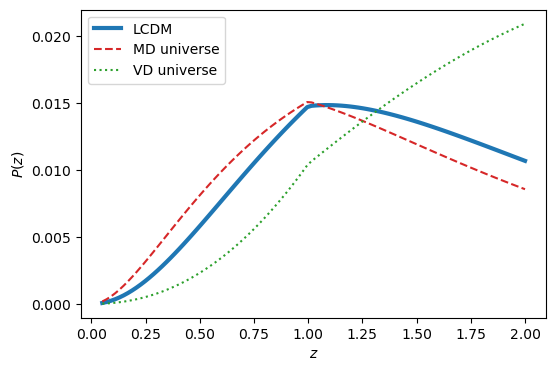

In [7]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(111)

ax1.plot(redshift_array, Distribution_redshift(redshift_array, HUBBLE, OMEGA_MATTER), label='LCDM', c='tab:blue', lw=3)
ax1.plot(redshift_array, Distribution_redshift(redshift_array, HUBBLE, 1), label='MD universe', c='tab:red', ls='--')
ax1.plot(redshift_array, Distribution_redshift(redshift_array, HUBBLE, 0), label='VD universe', c='tab:green', ls=':')

ax1.set_ylabel(r'$P(z)$')
ax1.set_xlabel(r'$z$')
ax1.legend(loc='upper left', fontsize=10)

plt.show()

Draw redshifts that follow the distribution

In [8]:
Pz_array = np.random.choice(redshift_array, size=5000, replace=True,\
                            p=Distribution_redshift(redshift_array, HUBBLE, OMEGA_MATTER))
Uniform_z_array = np.random.choice(redshift_array, size=5000, replace=True)

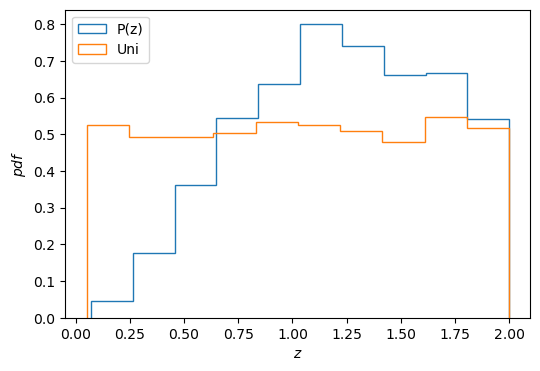

In [9]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(111)

ax1.hist(Pz_array, density=True, histtype='step', label='P(z)')
ax1.hist(Uniform_z_array, density=True, histtype='step', label='Uni')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$pdf$')
ax1.legend(loc='upper left', fontsize=10)

plt.show()

From Jin-Ping Zhu's paper

The Gaussian delay model

In [10]:
def Distribution_redshift_Gaussian(z, epi=-7.553):
    f=(1+z)**(3.879*epi)+((1+z)/73.5)**(-0.4901*epi)+((1+z)/3.672)**(-5.691*epi)+((1+z)/3.411)**(-11.46*epi)+((1+z)/3.546)**(-16.38*epi)+((1+z)/3.716)**(-20.66*epi)
    f=f**(1/epi)
    
    return normalise(f)

def Distribution_redshift_LogNormal(z, epi=-5.51):
    f=(1+z)**(4.131*epi)+((1+z)/22.37)**(-0.5789*epi)+((1+z)/2.978)**(-4.735*epi)+((1+z)/2.749)**(-10.77*epi)+((1+z)/2.867)**(-17.51*epi)+((1+z)/3.04)**(-(0.08148+z**0.574/0.08682)*epi)
    f=f**(1/epi)
    
    return normalise(f)

def Distribution_redshift_Power(z, epi=-8.161):
    f=(1+z)**(1.895*epi)+((1+z)/5.722)**(-3.759*epi)+((1+z)/11.55)**(-0.7426*epi)
    f=f**(1/epi)
    
    return normalise(f)

In [11]:
Pz_gaussian = np.random.choice(redshift_array, size=5000, replace=True,\
                            p=Distribution_redshift_Gaussian(redshift_array))
Pz_empirical = np.random.choice(redshift_array, size=5000, replace=True,\
                            p=Distribution_redshift_Empirical(redshift_array))
Pz_power = np.random.choice(redshift_array, size=5000, replace=True,\
                            p=Distribution_redshift_Power(redshift_array))

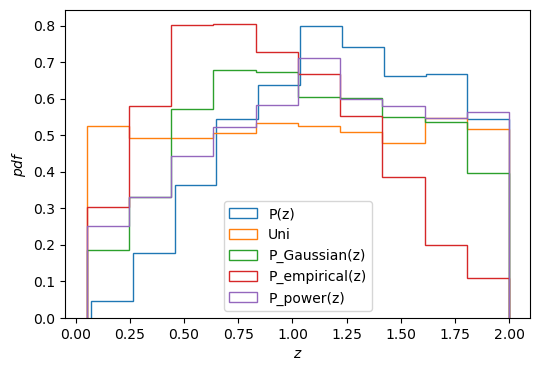

In [14]:
fig = plt.figure(figsize=(6,4))
ax1 = fig.add_subplot(111)

ax1.hist(Pz_array, density=True, histtype='step', label='P(z)')
ax1.hist(Uniform_z_array, density=True, histtype='step', label='Uni')
ax1.hist(Pz_gaussian, density=True, histtype='step', label='P_Gaussian(z)')
ax1.hist(Pz_empirical, density=True, histtype='step', label='P_empirical(z)')
ax1.hist(Pz_power, density=True, histtype='step', label='P_power(z)')

ax1.set_xlabel(r'$z$')
ax1.set_ylabel(r'$pdf$')
ax1.legend(fontsize=10)

plt.show()

### 4.Realistic luminosity distance posteriors

Choose waveforms and errors from [[1009.0206](https://arxiv.org/abs/1009.0206)]?